In [17]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

from sklearn.model_selection import KFold

from sklearn.metrics import (
    matthews_corrcoef,
    balanced_accuracy_score,
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    roc_auc_score
)
#from google.colab import drive
#drive.mount('/content/drive')

# Baseline model: logistic regressor

In [ ]:
train_df = pd.read_parquet("classification_ring/data/processed/train.parquet")
val_df = pd.read_parquet("classification_ring/data/processed/val.parquet") # dont load the test set yet, we will use it only at the very end to evaluate the final classifier
train_df.head()

,pdb_id,s_ch,s_resi,s_ins,s_resn,s_ss8,s_rsa,s_phi,s_psi,s_a1,...,t_a5,t_3di_state,t_3di_letter,HBOND,IONIC,PICATION,PIHBOND,PIPISTACK,SSBOND,VDW
0,2i49,A,444,,L,H,0.073,-0.990,-0.759,-1.019,...,1.648,5.0,F,0,0,0,0,0,0,1
1,2i49,A,157,,A,-,0.000,-1.132,2.664,-0.591,...,-0.078,1.0,B,1,0,0,0,0,0,1
2,2i49,A,81,,G,T,0.357,1.342,0.258,-0.384,...,1.648,17.0,R,1,0,0,0,0,0,0
3,2i49,A,172,,A,G,0.009,-1.754,0.040,-0.591,...,0.816,13.0,N,1,0,0,0,0,0,0
4,2i49,A,316,,G,S,0.310,-0.955,2.750,-0.384,...,0.933,17.0,R,1,0,0,0,0,0,1


Preparation of X and Y

In [5]:
pair_cols = [
    "pdb_id",
    "s_ch", "s_resi", "s_ins", "s_resn",
    "t_ch", "t_resi", "t_ins", "t_resn"
]

label_cols = ['HBOND', 'VDW', 'IONIC', 'PIPISTACK', 'PICATION', 'SSBOND', 'PIHBOND']

#Numerical features
num_features = [
    's_rsa', 's_phi', 's_psi', 's_a1', 's_a2', 's_a3', 's_a4', 's_a5',
    's_3di_state',
    't_rsa', 't_phi', 't_psi', 't_a1', 't_a2', 't_a3', 't_a4', 't_a5',
    't_3di_state'
]

#Categorical features
cat_features = [
    's_ss8', 's_3di_letter',
    't_ss8', 't_3di_letter'
]



feature_cols = num_features + cat_features

X_train = train_df[feature_cols]
Y_train = train_df[label_cols]

X_val = val_df[feature_cols]
Y_val = val_df[label_cols]

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)

X_train shape: (999083, 22)
Y_train shape: (999083, 7)


Preproccessing to clean the features

In [6]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer # apply different preprocessing steps to different columns
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier # train a separate classifier for each output label (one vs rest)
from sklearn.impute import SimpleImputer # fills in missing values with a specified strategy (mean, median, mode, etc.)
#Imputing was necessary because we of NaN vaues
# Numerical:impute with median then scale



num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical:impute with most frequent,then encode
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # handle_unknown='ignore' ensures that if a category appears in the test set that wasn't seen in the training set, it won't cause an error. Instead, it will be ignored and encoded as all zeros.
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

lr_model = MultiOutputClassifier(
    LogisticRegression(
        class_weight='balanced', # helps to handle class imbalance by adjusting the weights inversely proportional to class frequencies in the input data. Model learns to pay more attention to the minority class.
        max_iter=1000,
        random_state=42
    )
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', lr_model)
    ],
    verbose = True # prints some logging, which might be useful to see the progress of the training
)

print("Pipeline built successfully")

Pipeline built successfully


Optional: optimize threshold choice for each class, using cross validation

In [ ]:
# TODO (maybe): Implement K-fold cross validation: choose optimal threshold for each class as the one that maximizes average cross validation MCC.
# In case, uncomment and complete the following code:

"""
cv = KFold(n_splits=5, shuffle=True, random_state=42)


results = []


for fold, (train_idx, val_idx) in enumerate(cv.split(X_train), start=1):

    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]

    Y_tr = Y_train.iloc[train_idx]
    Y_val = Y_train.iloc[val_idx]

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", lr_model)
    ])

    print(f"Training fold {fold}")
    model.fit(X_tr, Y_tr)

    Y_score = model.predict_proba(X_val)
    Y_pred = model.predict(X_val) # by default, uses the threshold of 0.5

    # If predict_proba returns a list, one array per class
    if isinstance(Y_score, list):
        Y_score = np.column_stack([p[:, 1] for p in Y_score])

    for class_idx, class_name in enumerate(Y_train.columns):

        y_true = Y_val.iloc[:, class_idx]
        y_pred = Y_pred[:, class_idx]
        y_score = Y_score[:, class_idx]

        results.append({
            "fold": fold,
            "class": class_name,
            "MCC": matthews_corrcoef(y_true, y_pred), # thrs=0.5
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred), #thrs=0.5
            "average_precision": average_precision_score(y_true, y_score), # varies thrs internally
            "ROC_AUC": roc_auc_score(y_true, y_score)
        })

cv_results_df = pd.DataFrame(results)
cv_results_df




os.makedirs("classification_ring/models/logistic_classifier", exist_ok=True)
cv_results_df.to_csv("classification_ring/models/logistic_classifier/cv_results.csv", index=False)


cv_summary = (
    cv_results_df
    .groupby("class")[["MCC", "balanced_accuracy", "average_precision", "ROC_AUC"]]
    .agg(["mean", "std"])
)

cv_summary.to_csv("classification_ring/models/logistic_classifier/cv_summary.csv")
cv_summary

"""

'\ncv = KFold(n_splits=5, shuffle=True, random_state=42)\n\n\nresults = []\n\n\nfor fold, (train_idx, val_idx) in enumerate(cv.split(X_train), start=1):\n\n    X_tr = X_train.iloc[train_idx]\n    X_val = X_train.iloc[val_idx]\n\n    Y_tr = Y_train.iloc[train_idx]\n    Y_val = Y_train.iloc[val_idx]\n\n    model = Pipeline([\n        ("preprocessor", preprocessor),\n        ("classifier", lr_model)\n    ])\n\n    print(f"Training fold {fold}")\n    model.fit(X_tr, Y_tr)\n\n    Y_score = model.predict_proba(X_val)\n    Y_pred = model.predict(X_val) # by default, uses the threshold of 0.5\n\n    # If predict_proba returns a list, one array per class\n    if isinstance(Y_score, list):\n        Y_score = np.column_stack([p[:, 1] for p in Y_score])\n\n    for class_idx, class_name in enumerate(Y_train.columns):\n\n        y_true = Y_val.iloc[:, class_idx]\n        y_pred = Y_pred[:, class_idx]\n        y_score = Y_score[:, class_idx]\n\n        results.append({\n            "fold": fold,\n   

#### Train on all data

In [9]:
print("Training")
pipeline.fit(X_train, Y_train)
print("Training complete!")

Training
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   2.8s
[Pipeline] ........ (step 2 of 2) Processing classifier, total=  32.5s
Training complete!


---
---
# Evaluation on the validation set


Suggested metrics: 

- MCC (*), 
- BA (*) (Balanced Accuracy), 
- Average Precision (**) (area under the Precision-Recall curve)
- AUC ROC (**) (area under the Receiver-Operating Characteristic)


(*): depends on prediction threshold, (**): global metric, just depends on the scores.

In [18]:
"""
from sklearn.metrics import classification_report, f1_score
import numpy as np
Y_pred = pipeline.predict(X_val)

print("=" * 60)
print("For each Class Results on VALIDATION SET")
print("=" * 60)

for i, label in enumerate(label_cols):
    print(f"\n--- {label} ---")
    print(classification_report(
        Y_val.iloc[:, i],
        Y_pred[:, i],
        target_names=['absent', 'present'],
        zero_division=0
    ))
macro_f1 = f1_score(Y_val, Y_pred, average='macro', zero_division=0)
micro_f1 = f1_score(Y_val, Y_pred, average='micro', zero_division=0)
print(f"\nMacro F1: {macro_f1:.4f}")
print(f"Micro F1: {micro_f1:.4f}")
"""

'\nfrom sklearn.metrics import classification_report, f1_score\nimport numpy as np\nY_pred = pipeline.predict(X_val)\n\nprint("=" * 60)\nprint("For each Class Results on VALIDATION SET")\nprint("=" * 60)\n\nfor i, label in enumerate(label_cols):\n    print(f"\n--- {label} ---")\n    print(classification_report(\n        Y_val.iloc[:, i],\n        Y_pred[:, i],\n        target_names=[\'absent\', \'present\'],\n        zero_division=0\n    ))\nmacro_f1 = f1_score(Y_val, Y_pred, average=\'macro\', zero_division=0)\nmicro_f1 = f1_score(Y_val, Y_pred, average=\'micro\', zero_division=0)\nprint(f"\nMacro F1: {macro_f1:.4f}")\nprint(f"Micro F1: {micro_f1:.4f}")\n'

In [ ]:
# Compute all metrics and stores in dataframes

target_names = label_cols

# ------------------------------------------------------------
# 1. Get predicted probabilities
# ------------------------------------------------------------

def get_positive_class_scores(model, X):
    """
    Return an array of shape (n_samples, n_classes)
    containing P(class = 1) for each class.
    """
    y_proba = model.predict_proba(X)

    # Multi-label case: list of arrays, one per class
    if isinstance(y_proba, list):
        y_scores = np.column_stack([proba[:, 1] for proba in y_proba])

    # Binary/multiclass single-output case
    else:
        y_scores = y_proba[:, 1]

    return y_scores


y_scores = get_positive_class_scores(pipeline, X_val)

thresholds = np.arange(0.00, 1.01, 0.01)

threshold_results = []
curve_results = []

# ------------------------------------------------------------
# 2. Compute metrics class by class
# ------------------------------------------------------------

for class_idx, class_name in enumerate(target_names):

    y_true = Y_val.iloc[:, class_idx].values
    y_score = y_scores[:, class_idx]

    # --------------------------------------------------------
    # Threshold-dependent metrics
    # --------------------------------------------------------

    for threshold in thresholds:

        y_pred = (y_score >= threshold).astype(int)

        threshold_results.append({
            "class": class_name,
            "threshold": threshold,
            "MCC": matthews_corrcoef(y_true, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred)
        })

    # --------------------------------------------------------
    # Threshold-independent curve data
    # --------------------------------------------------------

    precision, recall, pr_thresholds = precision_recall_curve(
        y_true,
        y_score
    )

    fpr, tpr, roc_thresholds = roc_curve(
        y_true,
        y_score
    )

    ap = average_precision_score(
        y_true,
        y_score
    )

    auc = roc_auc_score(
        y_true,
        y_score
    )

    curve_results.append({
        "class": class_name,
        "precision": precision,
        "recall": recall,
        "pr_thresholds": pr_thresholds,
        "fpr": fpr,
        "tpr": tpr,
        "roc_thresholds": roc_thresholds,
        "average_precision": ap,
        "ROC_AUC": auc
    })

# ------------------------------------------------------------
# 3. Convert to DataFrames
# ------------------------------------------------------------

threshold_results_df = pd.DataFrame(threshold_results)
curve_results_df = pd.DataFrame(curve_results)

In [12]:
best_thresholds_df = (
    threshold_results_df
    .sort_values(["class", "MCC"], ascending=[True, False])
    .groupby("class")
    .head(1)
    .reset_index(drop=True)
)

best_thresholds_df

,class,threshold,MCC,balanced_accuracy
0,HBOND,0.43,0.228440,0.613222
1,IONIC,0.71,0.419045,0.921960
2,PICATION,0.74,0.311698,0.948478
3,PIHBOND,0.81,0.058638,0.747098
4,PIPISTACK,0.81,0.623690,0.976372
5,SSBOND,0.99,0.869555,0.999708
6,VDW,0.52,0.130817,0.563785


In [13]:
curve_summary_df = curve_results_df[
    ["class", "average_precision", "ROC_AUC"]
]

curve_summary_df

,class,average_precision,ROC_AUC
0,HBOND,0.827902,0.668367
1,VDW,0.586199,0.592395
2,IONIC,0.315793,0.966008
3,PIPISTACK,0.458711,0.981453
4,PICATION,0.083716,0.968756
5,SSBOND,0.886711,0.999844
6,PIHBOND,0.007049,0.910205


### Plots

Plot MCC and balanced accuracy vs threshold for each class

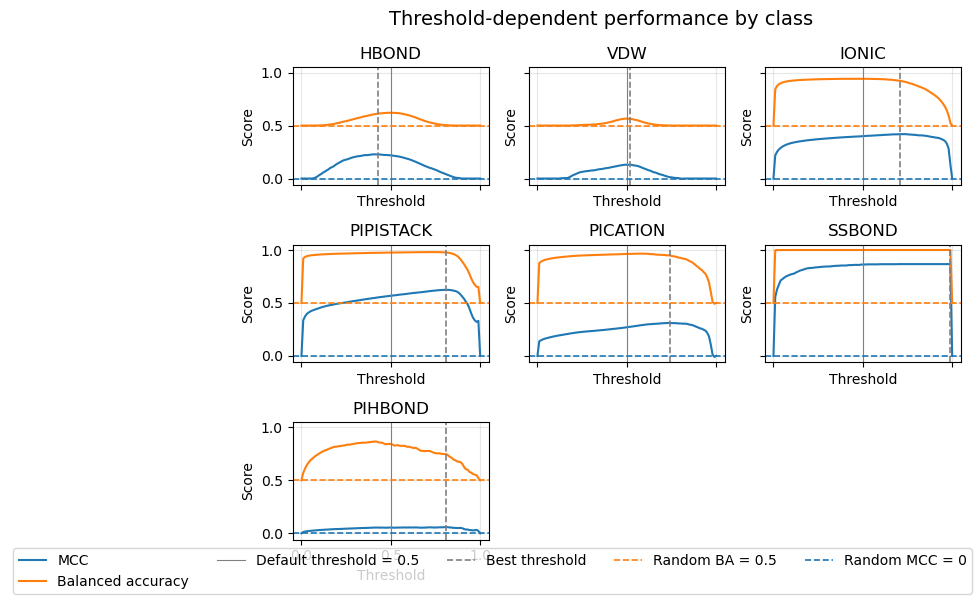

In [26]:

n_classes = len(target_names)
n_cols = 3
n_rows = math.ceil(n_classes / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(2.5 * n_cols, 2 * n_rows),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for class_idx, class_name in enumerate(target_names):

    ax = axes[class_idx]

    class_results = threshold_results_df[
        threshold_results_df["class"] == class_name
    ]

    ax.plot(
        class_results["threshold"],
        class_results["MCC"],
        label="MCC"
    )

    ax.plot(
        class_results["threshold"],
        class_results["balanced_accuracy"],
        label="Balanced accuracy"
    )

    ax.axvline(
        x=0.5,
        color="grey",
        lw=0.8,
        ls="solid",
        label="Default threshold = 0.5"
    )

    ax.axvline(
        x=best_thresholds_df.loc[best_thresholds_df["class"] == class_name, "threshold"].values[0],
        color="grey",
        lw=1.2,
        ls="dashed",
        label="Best threshold"
    )

    ax.axhline(
        y=0.5,
        color="tab:orange",
        lw=1.2,
        ls="dashed",
        label="Random BA = 0.5"
    )

    ax.axhline(
        y=0.0,
        color="tab:blue",
        lw=1.2,
        ls="dashed",
        label="Random MCC = 0"
    )



    ax.set_title(class_name)
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.grid(alpha=0.3)

# Switch off unused axes
for ax in axes[n_classes:]:
    ax.axis("off")

# Single shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower right",
    ncol=5,
    frameon=True
)

fig.suptitle(
    "Threshold-dependent performance by class",
    fontsize=14
)

plt.tight_layout()
plt.show()

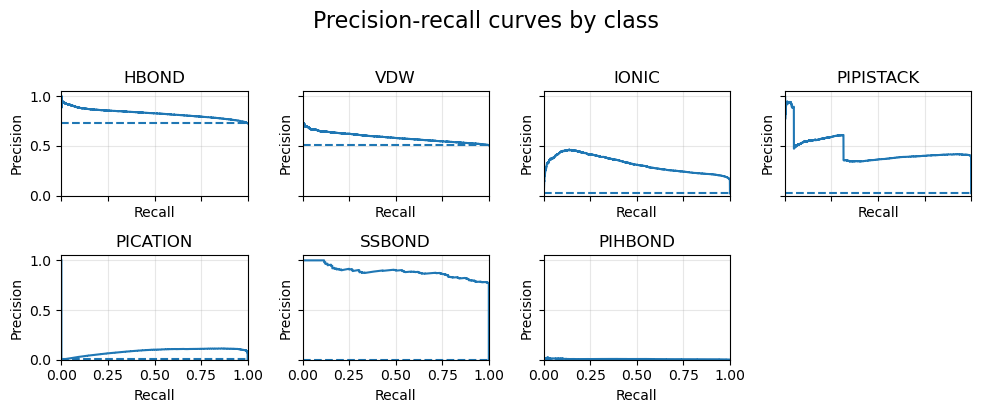

In [30]:
import numpy as np
import matplotlib.pyplot as plt

n_classes = len(target_names)

n_cols = 4
n_rows = int(np.ceil(n_classes / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(2.5 * n_cols, 2 * n_rows),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for class_idx, class_name in enumerate(target_names):

    ax = axes[class_idx]

    row = curve_results_df[
        curve_results_df["class"] == class_name
    ].iloc[0]

    precision = row["precision"]
    recall = row["recall"]
    ap = row["average_precision"]

    # baseline = prevalence of the positive class
    y_true_class = (
        Y_val.iloc[:, class_idx].values
        if hasattr(Y_val, "iloc")
        else Y_val[:, class_idx]
    )
    prevalence = np.mean(y_true_class)

    ax.plot(
        recall,
        precision,
        label=f"PR curve, AP = {ap:.3f}"
    )

    ax.axhline(
        prevalence,
        linestyle="--",
        label=f"Random baseline = {prevalence:.3f}"
    )


    ax.set_title(class_name)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)

# remove empty panels
for ax in axes[n_classes:]:
    ax.axis("off")




fig.suptitle(
    "Precision-recall curves by class",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

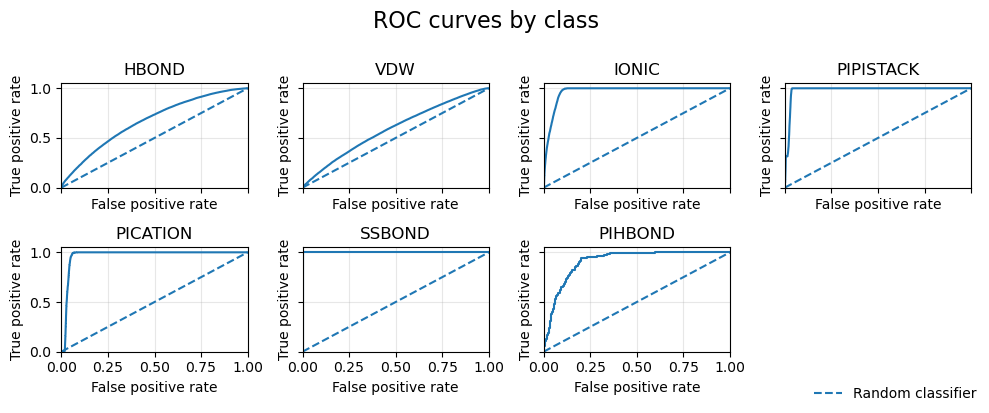

In [38]:
n_classes = len(target_names)

n_cols = 4
n_rows = int(np.ceil(n_classes / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(2.5 * n_cols, 2 * n_rows),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for class_idx, class_name in enumerate(target_names):

    ax = axes[class_idx]

    row = curve_results_df[
        curve_results_df["class"] == class_name
    ].iloc[0]

    ax.plot(
        row["fpr"],
        row["tpr"],
        #label=f"ROC curve, AUC = {row['ROC_AUC']:.3f}"
    )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color = "tab:blue",
        label="Random classifier"
    )

    ax.set_title(class_name)
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)

# remove empty panels
for ax in axes[n_classes:]:
    ax.axis("off")

# shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower right",
    ncol=2,
    frameon=False
)

fig.suptitle(
    "ROC curves by class",
    fontsize=16,
    y=1
)

plt.tight_layout()
plt.show()

---
# Diagnostics

Any analysis used to understand better why we got the results we got, and guide design decisions for better classifiers

Looking at the *scores* distirbutions: which classes are most clearly linearly separated? These plots should complement and confirm the BA plots.

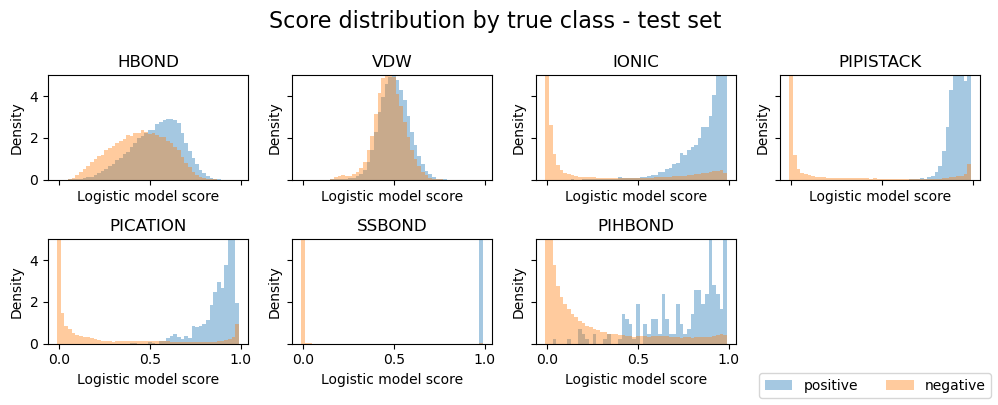

In [45]:

fig, axes = plt.subplots(2, len(target_names)//2 + 1, figsize=(10, 4),
                         sharex=True, sharey=True)

plt.suptitle("Score distribution by true class - test set", fontsize=16)
axes = axes.flatten()
axes[-1].axis('off') 


for class_idx, class_name in enumerate(target_names):
    y_true_class = Y_val.iloc[:, class_idx] if hasattr(Y_val, "iloc") else Y_val[:, class_idx]
    scores = y_scores[:, class_idx]
    positives = scores[y_true_class == 1]
    negatives = scores[y_true_class == 0]
    poscounts, posbins = np.histogram(positives, bins=50, range=(0, 1), density=True)
    negcounts, negbins = np.histogram(negatives, bins=50, range=(0, 1), density=True)
    ax = axes[class_idx]
    ax.bar(posbins[:-1], poscounts, width=np.diff(posbins), label="positive", alpha=0.4)
    ax.bar(negbins[:-1], negcounts, width=np.diff(negbins), label="negative", alpha=0.4)
    ax.set_xlabel("Logistic model score")
    ax.set_ylabel("Density")
    #ax.legend(title = f"{target_names[class_idx]}")
    ax.set_ylim(0, 5) # zoom in to look at misclassifications better
    ax.set_title(class_name)



handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower right",
    ncol=2,
    frameon=True
)
plt.tight_layout()

plt.show()

**Observations**:


The logistic score is the composition of the sigmoid function with a linear map.
$$
score(x) = \sigma \left(\sum_{i}^{n.features} w_i x_i + w_0 \right)
$$

Separation of the scores shows how well it is possible to perform each binary one-vs-rest classification by using a linear boundary decision.

- SSBOND class is perfectly separated, as it was expected, being the chemistry of the SSBOND totally restrictive.The signal is very strong.
- PICATION, IONIC, and PIPISTACK are well separated, **but** with a large number of **false positives**. This should be looked into.
    - false positives affect MCC and PR-curve (precision), while they do not affect the balanced accuracy and the ROC. 
    - The fact that the classifier separates quite well positives and negatives, while still producing a lot of false positives, explains perfectly why these classes display low MCC and a low PR-curve, while still having good values of ROC and BA.
- PIHBOND is only moderately separated by a linear boundary.
- VDW and HBOND classes are not separable at all with a linear boundary. Their signal is very weak.





**TODO**: since false positives are the main source of error, next we inspect were they come from.





- Inspect the false positives. Some classes may be hard because their labels are not independent. For example, ionic contacts and hydrogen bonds may overlap; aromatic contacts may overlap with pi-stacking or pi-cation patterns.

- For each class, inspect feature separability.
  A simple start is to compare feature means between positives and negatives.


- For a linear model, also inspect coefficients:
    This helps answer:

        * Is the model using chemically meaningful features?
        * Are poor classes associated with weak or diffuse coefficients?
        * Are some classes relying on features that are not class-specific?
        * Are geometric features missing?

# Inspection of the false positives 

In [63]:
import pandas as pd
import numpy as np

# Baseline prevalence of each label in the validation set
label_prevalence = Y_val.mean().sort_values(ascending=False)

# First row of final dataframe
prevalence_rows = {
    "baseline": label_prevalence
}

false_positive_counts = {}

Y_pred = pipeline.predict(X_val)

# Make sure Y_pred is a DataFrame with same columns/index as Y_val
Y_pred_df = pd.DataFrame(
    Y_pred,
    columns=Y_val.columns,
    index=Y_val.index
)

for class_idx, class_name in enumerate(target_names):

    # Samples predicted as class_name, but truly not class_name
    fp_mask = (Y_val.iloc[:, class_idx] == 0) & (Y_pred_df.iloc[:, class_idx] == 1)

    false_positives = Y_val.loc[fp_mask]

    n_fp = len(false_positives)
    false_positive_counts[class_name] = n_fp

    if n_fp == 0:
        print(f"\nNo false positives for {class_name}")
        continue

    # Drop the class itself, since it is necessarily 0 among its false positives
    false_positives_no_self = false_positives.drop(columns=[class_name])

    # Prevalence of true labels among false positives
    fp_label_prevalence = false_positives_no_self.mean()

    # Add as a row
    prevalence_rows[f"FP_{class_name}"] = fp_label_prevalence

# Final dataframe
fp_prevalence_df = pd.DataFrame(prevalence_rows).T

# Optional: inspect number of false positives per predicted class
false_positive_counts = pd.Series(false_positive_counts, name="n_false_positives")


display(fp_prevalence_df)
print(false_positive_counts)

,HBOND,IONIC,PICATION,PIHBOND,PIPISTACK,SSBOND,VDW
baseline,0.727294,0.022955,0.006277,0.000888,0.024530,0.001809,0.506566
FP_HBOND,NaN,0.012812,0.016896,0.001049,0.004271,0.000000,0.981531
FP_VDW,0.944421,0.024537,0.009297,0.001426,0.054153,0.003373,NaN
FP_IONIC,0.827698,NaN,0.005499,0.000164,0.000000,0.000000,0.491834
FP_PIPISTACK,0.591136,0.000000,0.030568,0.005606,NaN,0.037838,0.589735
FP_PICATION,0.644976,0.000000,NaN,0.001779,0.095714,0.000000,0.559706
FP_SSBOND,0.648649,0.000000,0.000000,0.000000,0.000000,NaN,0.547297
FP_PIHBOND,0.587994,0.004387,0.026200,NaN,0.138164,0.010529,0.568497


HBOND        26693
VDW          49803
IONIC        24370
PIPISTACK    11417
PICATION     17427
SSBOND         148
PIHBOND      41031
Name: n_false_positives, dtype: int64


In [65]:
enrichment_df = (fp_prevalence_df - fp_prevalence_df.loc["baseline"]) / fp_prevalence_df.loc["baseline"]
enrichment_df = enrichment_df.drop(index="baseline")  # Exclude the baseline row 
enrichment_df = enrichment_df[[class_name for class_name in target_names]]


display(enrichment_df)

,HBOND,VDW,IONIC,PIPISTACK,PICATION,SSBOND,PIHBOND
FP_HBOND,NaN,0.937617,-0.441861,-0.825895,1.691721,-1.000000,0.181619
FP_VDW,0.298542,NaN,0.068881,1.207642,0.481073,0.864758,0.605904
FP_IONIC,0.138052,-0.029081,NaN,-1.000000,-0.124008,-1.000000,-0.815107
FP_PIPISTACK,-0.187211,0.164181,-1.000000,NaN,3.869948,19.917054,5.314582
FP_PICATION,-0.113183,0.104903,-1.000000,2.901904,NaN,-1.000000,1.003806
FP_SSBOND,-0.108134,0.080407,-1.000000,-1.000000,-1.000000,NaN,-1.000000
FP_PIHBOND,-0.191531,0.122257,-0.808894,4.632452,3.173950,4.820233,NaN


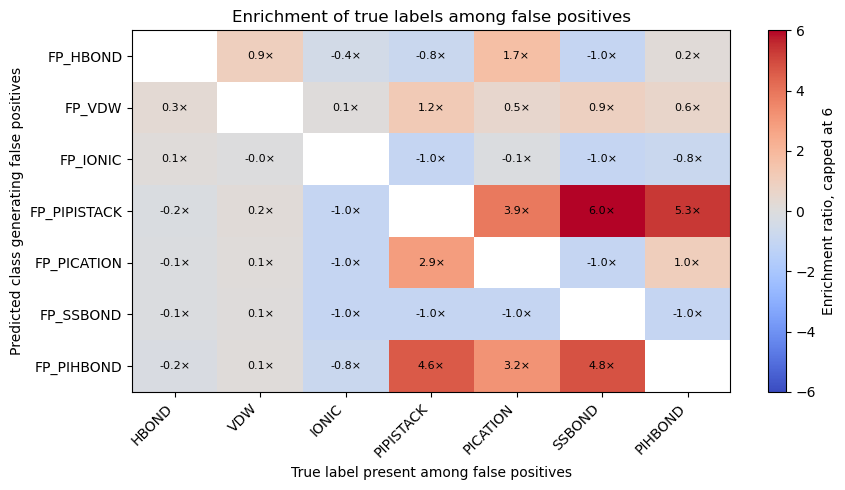

In [68]:
plot_df = enrichment_df.clip(upper=6) 

fig, ax = plt.subplots(figsize=(9, 5))

import matplotlib.colors as mcolors

vmax = np.nanmax(np.abs(plot_df.values))
vmin = -vmax

norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

im = ax.imshow(
    plot_df,
    aspect="auto",
    cmap="coolwarm",
    norm=norm
)

ax.set_xticks(np.arange(plot_df.shape[1]))
ax.set_yticks(np.arange(plot_df.shape[0]))

ax.set_xticklabels(plot_df.columns, rotation=45, ha="right")
ax.set_yticklabels(plot_df.index)

ax.set_xlabel("True label present among false positives")
ax.set_ylabel("Predicted class generating false positives")
ax.set_title("Enrichment of true labels among false positives")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Enrichment ratio, capped at 6")

for i in range(plot_df.shape[0]):
    for j in range(plot_df.shape[1]):
        value = plot_df.iloc[i, j]
        if not np.isnan(value):
            ax.text(j, i, f"{value:.1f}×", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

---
## Model weights: which features are most useful?

In [70]:
# Extract fitted parts
preprocessor = pipeline.named_steps["preprocessor"]
classifier = pipeline.named_steps["classifier"]

# Feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# One LogisticRegression model per class
estimators = classifier.estimators_

# Store coefficients class by class
coef_tables = {}

for class_idx, class_name in enumerate(target_names):
    model = estimators[class_idx]

    coefs = model.coef_[0]

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefs,
        "abs_coefficient": np.abs(coefs)
    }).sort_values("abs_coefficient", ascending=False)

    coef_tables[class_name] = coef_df

display(coef_tables["SSBOND"].head(15))

,feature,coefficient,abs_coefficient
12,num__t_a1,-10.985235,10.985235
3,num__s_a1,-10.673809,10.673809
14,num__t_a3,-6.415252,6.415252
5,num__s_a3,-6.414272,6.414272
7,num__s_a5,6.012176,6.012176
16,num__t_a5,5.755745,5.755745
51,cat__t_ss8_H,-4.238898,4.238898
55,cat__t_ss8_T,-4.046939,4.046939
18,cat__s_ss8_-,-3.696318,3.696318
22,cat__s_ss8_H,-3.489866,3.489866


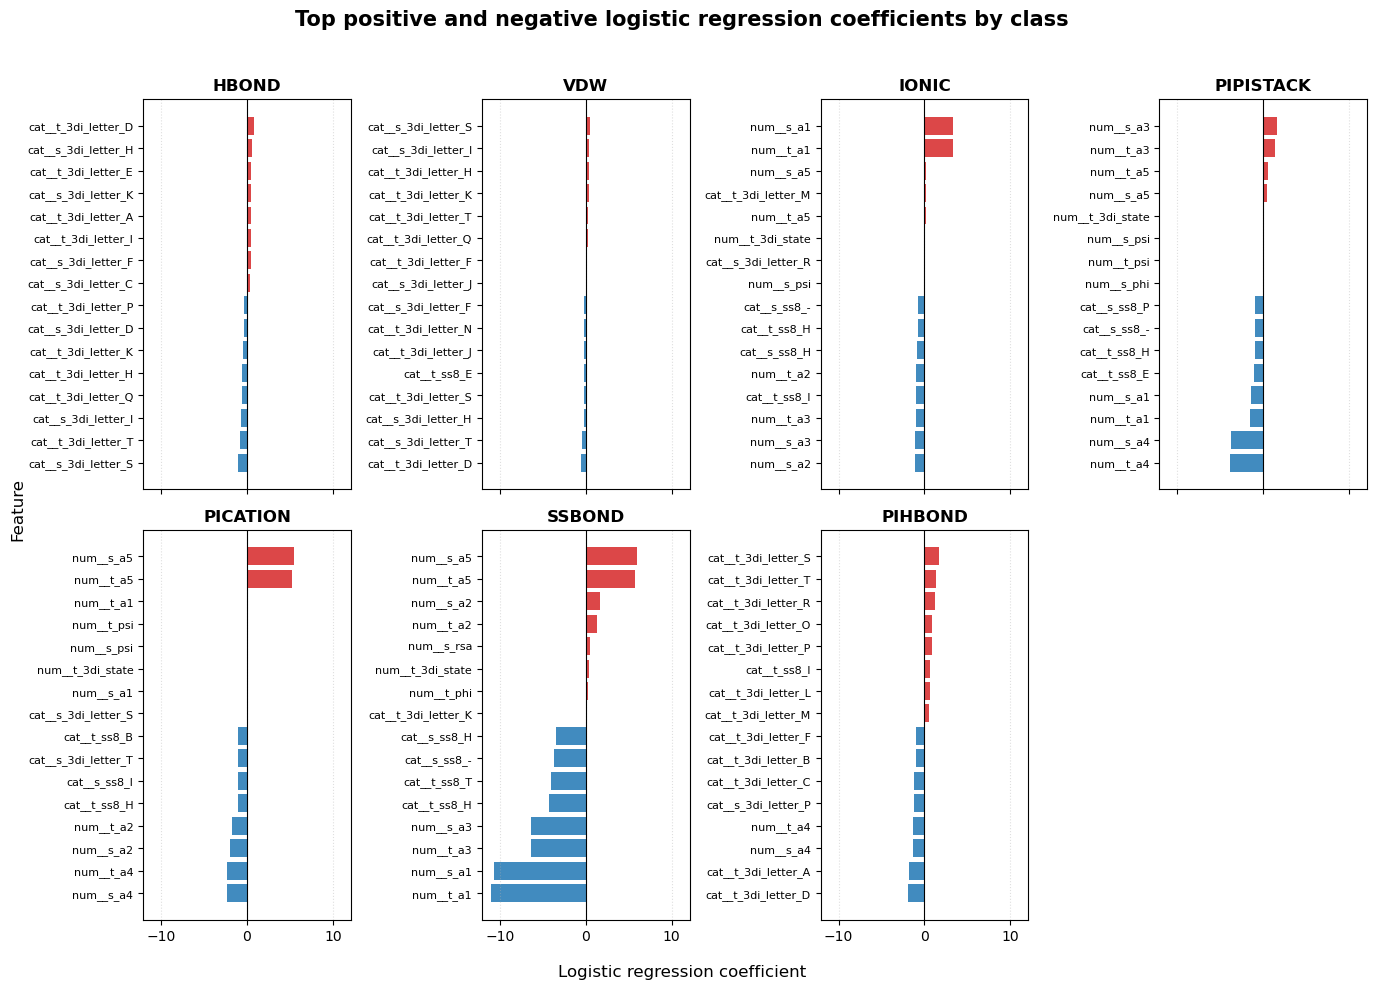

In [74]:
import math
top_each_side = 8

coef_plot_tables = {}

for class_name, coef_df in coef_tables.items():

    top_positive = (
        coef_df
        .sort_values("coefficient", ascending=False)
        .head(top_each_side)
    )

    top_negative = (
        coef_df
        .sort_values("coefficient", ascending=True)
        .head(top_each_side)
    )

    plot_df = (
        pd.concat([top_negative, top_positive])
        .drop_duplicates(subset="feature")
        .sort_values("coefficient")
        .copy()
    )

    coef_plot_tables[class_name] = plot_df

# Shared x-axis limits
max_abs_coef = max(
    df["coefficient"].abs().max()
    for df in coef_plot_tables.values()
)

xlim = (-1.1 * max_abs_coef, 1.1 * max_abs_coef)

n_classes = len(coef_plot_tables)
n_cols = 4
n_rows = math.ceil(n_classes / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 4.8 * n_rows),
    sharex=True
)

axes = np.array(axes).reshape(-1)

for ax, (class_name, plot_df) in zip(axes, coef_plot_tables.items()):

    y_pos = np.arange(len(plot_df))

    colors = np.where(
        plot_df["coefficient"] >= 0,
        "tab:red",
        "tab:blue"
    )

    ax.barh(
        y_pos,
        plot_df["coefficient"],
        color=colors,
        alpha=0.85
    )

    ax.axvline(0, color="black", linewidth=0.8)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_df["feature"], fontsize=8)

    ax.set_title(class_name, fontsize=12, fontweight="bold")
    ax.set_xlim(xlim)

    ax.grid(axis="x", linestyle=":", alpha=0.4)

for ax in axes[len(coef_plot_tables):]:
    ax.axis("off")

fig.supxlabel("Logistic regression coefficient")
fig.supylabel("Feature")

fig.suptitle(
    f"Top positive and negative logistic regression coefficients by class",
    fontsize=15,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

#### Comments


From the feature usage class by class, it appears that the logistic classifier has learned quite well which kind of interaction types depend more on the *geometry* and which have instead a strong *chemical signature*.

On the one end, the model relies moslty on 3d environment descriptors for identifying HBONDS. This makes sense, since HBONDS are highly directional while not having a distinctive chemical signature. Similarly, the model uses only 3d letter descriptors for detection of VDW interactions.


On the other end, the model mostly uses Achley factors to identify SSBONDS. This means that the model has implicitly learned to recognize Cysteine residues throught the Achley factor representation, even if it doesnt have the information about residue identity. Similarly, the model is relying mostly on Achley factors for detecting PICATION and PIPISTACK.